# 05 - So sanh Face Detection Models (SCRFD vs YOLOv8-Face-N vs YOLOv8-Face-M vs RetinaFace vs MTCNN vs YuNet)

**Muc tieu:** notebook nay so sanh 6 face detector theo cung 1 quy trinh danh gia de
kiem tra xem model dang dung trong he thong co thuc su la lua chon tot nhat cho bai toan
giam sat an ninh khong. Ket qua nay dung de bao cao, slide, va lam co so bo sung/doi model
sau nay neu can.

**6 model duoc so sanh (6 nhom kien truc khac nhau):**

| Model | Kien truc | Vai tro trong so sanh |
|---|---|---|
| **SCRFD** (qua `insightface`, buffalo_l) | Anchor-free, single-stage, ONNX Runtime | Model **dang dung that** trong `backend/` |
| **YOLOv8-Face-N** | YOLO backbone nho, fine-tune rieng cho mat | Dai dien cho nhom YOLO nhe, uu tien toc do |
| **YOLOv8-Face-M** | YOLO backbone lon hon, fine-tune rieng cho mat | So sanh tac dong cua viec tang capacity model |
| **RetinaFace** (qua `insightface` model zoo) | One-stage detector co landmark head | Model face detector co tieng, manh o tiny/occluded faces |
| **MTCNN** | Cascade CNN 3 tang (P-Net/R-Net/O-Net), kien truc co dien hon | Baseline "kinh dien" de thay ro cai gia phai tra khi dung kien truc cu hon |
| **YuNet** (OpenCV) | DNN face detector nhe, ONNX | Baseline nhe, rat phu hop de do FPS va recall tren mat nho |

**Bo du lieu danh gia:** WIDER FACE validation split, tai da co san trong
`ai/dataset/benchmarks/wider face/` (dung lai cau truc doc annotation tu Notebook 04,
Cell 8-10) - KHONG tai lai, KHONG doi cau truc thu muc.

**Phan cung:** may chay co GPU RTX 5070 (12GB VRAM) - notebook nay uu tien chay cac model
co ho tro CUDA tren GPU. Riêng YuNet chay qua OpenCV; dung luong nho, rat phu hop de lam
baseline real-time. MTCNN co the chay GPU neu PyTorch da cai dung.

**Cac phan doc lap co the chay rieng:**
- Phan A - Cai dat + tai 6 model
- Phan B - Danh gia tren WIDER FACE (Precision/Recall/F1 @ IoU>=0.5, recall theo kich thuoc mat)
- Phan C - Do toc do (FPS) tren GPU / CPU baseline
- Phan D - So sanh truc quan tren vai anh mau
- Phan E - Tong ket + bang so lieu cho bao cao


## Phan A - Cai dat thu vien va tai 6 model

`insightface` + `onnxruntime-gpu` va `ultralytics` (YOLOv8) da co tu Notebook 01/02.
Moi trong notebook nay: `RetinaFace` qua `insightface.model_zoo.get_model`, `YuNet`
(qua `cv2.FaceDetectorYN_create`) va 2 bien the `YOLOv8-Face-N/M` de so sanh toc do /
do chinh xac khi tang kich thuoc model.

**Luu y ve GPU RTX 5070:**
- `SCRFD`, `YOLOv8-Face-N`, `YOLOv8-Face-M`, `MTCNN`, `RetinaFace` co the chay tren CUDA neu
  moi truong da cai dung `onnxruntime-gpu` / PyTorch GPU.
- `YuNet` la baseline CPU nhe, giu lai de co moc tham chieu ve toc do va do on dinh.

Cac model file se duoc tai/nap khi can; neu may khong co internet o lan chay dau tien,
ban co the tai thu cong va dat vao dung duong dan trong cell ben duoi.


In [1]:
# ===== CELL A1: Go ban onnxruntime CPU (neu co) & cai ban GPU =====
# Neu may chua tung cai onnxruntime CPU, dong pip uninstall se chi bao "not installed", khong sao.
!pip uninstall onnxruntime -y -q
!pip install -q onnxruntime-gpu

# facenet-pytorch (2.6.0) pin torch<2.3.0 trong metadata - RTX 5070 can torch>=2.7.0.
# Cai --no-deps de KHONG bi pip ha cap torch dang dung, roi tu cai bu 2 dependency
# khong lien quan torch (requests, tqdm) rieng - xem canh bao chi tiet o markdown tren.
!pip install -q --no-deps facenet-pytorch
!pip install -q requests tqdm

print("Da cai: onnxruntime-gpu (cho insightface/SCRFD), facenet-pytorch --no-deps (cho MTCNN)")
print("ultralytics (YOLOv8) va insightface da co tu Notebook 01/02, khong can cai lai")


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Da cai: onnxruntime-gpu (cho insightface/SCRFD), facenet-pytorch --no-deps (cho MTCNN)
ultralytics (YOLOv8) va insightface da co tu Notebook 01/02, khong can cai lai



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ===== CELL A1b: Xac nhan torch KHONG bi ha cap sau khi cai facenet-pytorch =====
import torch
print(f"Torch version sau khi cai facenet-pytorch: {torch.__version__}")
if torch.__version__.startswith(("2.0.", "2.1.", "2.2.")):
    print("CANH BAO: torch da bi ha cap xuong ban cu (< 2.3) - facenet-pytorch co the da "
          "duoc cai KHONG dung --no-deps, hoac 1 package khac keo torch xuong. RTX 5070 "
          "se KHONG chay duoc CUDA voi ban torch nay - can go va cai lai torch>=2.7 (cu128).")
else:
    print("Torch van dang o ban moi, chua bi facenet-pytorch keo xuong. On.")

Torch version sau khi cai facenet-pytorch: 2.11.0+cu128
Torch van dang o ban moi, chua bi facenet-pytorch keo xuong. On.


In [3]:
# ===== CELL A2: Kiem tra GPU co duoc nhan dien khong (PyTorch + ONNX Runtime) =====
import torch

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("KHONG thay GPU - kiem tra lai driver/CUDA toolkit truoc khi chay tiep, "
          "cac phep do FPS o Phan C se khong con y nghia so sanh voi GPU neu roi ve CPU.")

import onnxruntime as ort
print(f"\nONNX Runtime providers co san: {ort.get_available_providers()}")
if "CUDAExecutionProvider" not in ort.get_available_providers():
    print("CANH BAO: khong thay CUDAExecutionProvider - SCRFD se chay CPU (cham hon nhieu, "
          "so sanh FPS o Phan C se khong con cong bang giua 6 model).")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5070
VRAM: 12.8 GB

ONNX Runtime providers co san: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


In [4]:
# ===== CELL A3: Duong dan project =====
import os

BASE_DIR = r'D:\face-security-system'
AI_DIR = os.path.join(BASE_DIR, 'ai')

BENCHMARK_DIR = os.path.join(AI_DIR, 'dataset', 'benchmarks')
WIDER_FACE_DIR = os.path.join(BENCHMARK_DIR, 'wider face')
WIDER_VAL_IMAGES_DIR = os.path.join(WIDER_FACE_DIR, 'WIDER_val', 'images')
WIDER_VAL_ANNOTATION_PATH = os.path.join(
    WIDER_FACE_DIR, 'wider_face_annotations', 'wider_face_split', 'wider_face_val_bbx_gt.txt'
)

MODELS_DIR = os.path.join(AI_DIR, 'models')
RESULTS_DIR = os.path.join(AI_DIR, 'dataset', 'evaluation_results')
os.makedirs(RESULTS_DIR, exist_ok=True)

WIDER_FACE_AVAILABLE = os.path.exists(WIDER_VAL_IMAGES_DIR) and os.path.exists(WIDER_VAL_ANNOTATION_PATH)
if not WIDER_FACE_AVAILABLE:
    print("KHONG tim thay du lieu WIDER FACE tai:")
    print(f"  Anh:        {WIDER_VAL_IMAGES_DIR}")
    print(f"  Annotation: {WIDER_VAL_ANNOTATION_PATH}")
    print("Day la du lieu da tai o Notebook 04 - kiem tra lai duong dan BASE_DIR o tren "
          "neu chay tren may khac may da tai du lieu.")
else:
    print("Da tim thay du lieu WIDER FACE, san sang cho Phan B.")

Da tim thay du lieu WIDER FACE, san sang cho Phan B.


In [5]:
# ===== CELL A4: Tai model 1 - SCRFD (qua insightface, buffalo_l) =====
# Day chinh la model dang dung THAT trong backend/app/services/face_recognition_service.py
from insightface.app import FaceAnalysis

providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
scrfd_app = FaceAnalysis(name="buffalo_l", providers=providers)
# ctx_id=0 -> GPU dau tien neu CUDAExecutionProvider co san, insightface tu rot ve CPU neu khong
scrfd_app.prepare(ctx_id=0, det_size=(640, 640), det_thresh=0.3)  # det_thresh giong het config.py

print("Da tai SCRFD (buffalo_l)")
print(f"Providers dang dung: {scrfd_app.det_model.session.get_providers()}")

d:\face-security-system\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
find model: C:\Users\Admin/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'

In [6]:
# ===== CELL A5: Tải model 2/3 - YOLOv8-Face-N và YOLOv8-Face-M =====
import os
import urllib.request
import torch
from ultralytics import YOLO

# Đảm bảo biến MODELS_DIR đã được định nghĩa trước đó, ví dụ:
# MODELS_DIR = r"D:\face-security-system\ai\models"

def download_yolo_face_weights(filename: str, hf_subfolder: str) -> str:
    """
    Tải weights YOLO face từ Hugging Face (deepghs/yolo-face).
    File được ưu tiên lưu trong MODELS_DIR; nếu có sẵn thì không tải lại.
    """
    local_path = os.path.join(MODELS_DIR, filename)
    if os.path.exists(local_path):
        print(f"Đã có sẵn checkpoint: {local_path}")
        return local_path

    os.makedirs(MODELS_DIR, exist_ok=True)

    # Sử dụng nguồn Hugging Face ổn định thay cho GitHub release đã bị lỗi 404
    url = f"https://huggingface.co/deepghs/yolo-face/resolve/main/{hf_subfolder}/model.pt"
    try:
        print(f"Đang tải {filename} từ {url} ...")
        urllib.request.urlretrieve(url, local_path)
        print(f"Đã tải xong: {local_path}")
        return local_path
    except Exception as e:
        raise RuntimeError(
            f"Không thể tải {filename} từ Hugging Face. Lỗi: {e}. "
            f"Vui lòng tải thủ công và đặt vào: {local_path}"
        )

# Tải xuống với tên file mong muốn và subfolder tương ứng trên Hugging Face
YOLOV8_FACE_N_PATH = download_yolo_face_weights("yolov8n-face.pt", "yolov8n-face")
YOLOV8_FACE_M_PATH = download_yolo_face_weights("yolov8m-face.pt", "yolov8m-face")

# Khởi tạo model
yolo_face_n_model = YOLO(YOLOV8_FACE_N_PATH)
yolo_face_m_model = YOLO(YOLOV8_FACE_M_PATH)

print(f"Đã tải YOLOv8-Face-N và YOLOv8-Face-M, sẽ chạy trên: {'cuda' if torch.cuda.is_available() else 'cpu'}")

Đã có sẵn checkpoint: D:\face-security-system\ai\models\yolov8n-face.pt
Đã có sẵn checkpoint: D:\face-security-system\ai\models\yolov8m-face.pt
Đã tải YOLOv8-Face-N và YOLOv8-Face-M, sẽ chạy trên: cuda


In [7]:
# ===== CELL A6: Tai model 3 - MTCNN (cascade CNN co dien, qua facenet-pytorch) =====
from facenet_pytorch import MTCNN

device = "cuda" if torch.cuda.is_available() else "cpu"
mtcnn_model = MTCNN(
    keep_all=True,       # tra ve TAT CA mat tim duoc trong anh, khong chi 1 mat dep nhat
    device=device,
    min_face_size=20,     # gan giong nguong mac dinh cua SCRFD/YOLOv8-face de so sanh cong bang
    thresholds=[0.6, 0.7, 0.7],  # nguong 3 tang P-Net/R-Net/O-Net mac dinh cua MTCNN goc
)
print(f"Da tai MTCNN, dang chay tren: {device}")

Da tai MTCNN, dang chay tren: cuda


In [8]:
# ===== CELL A7-test: Kiem tra API retinaface-pytorch =====
from retinaface.pre_trained_models import get_model
import inspect

from retinaface.pre_trained_models import get_model

model = get_model(
    "resnet50_2020-07-20",
    max_size=2048
)
model.eval()

print("Cac method public:", [m for m in dir(model) if not m.startswith('_')])

# Thu detect 1 anh mau
import cv2, numpy as np
test_img = np.random.randint(0, 255, (480, 640, 3), dtype=np.uint8)
try:
    result = model.predict(test_img)
    print(f"predict() tra ve: type={type(result)}")
    if isinstance(result, (tuple, list)):
        print(f"  len={len(result)}, [0] type={type(result[0])}, shape={np.asarray(result[0]).shape}")
    elif isinstance(result, dict):
        print(f"  keys={list(result.keys())}")
except Exception as e:
    print(f"predict() loi: {e}")
    # Thu method khac
    for method_name in ['detect', 'forward', '__call__']:
        if hasattr(model, method_name):
            print(f"  Co method: {method_name}")

d:\face-security-system\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\face-security-system\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
d:\face-security-system\.venv\Lib\site-packages\torch\hub.py:897: FutureWarning: Falling back to the old format < 1.6. This support will be deprecated in favor of default zipfile format introduced in 1.6. Please redo torch.save() to save it in the new zipfile format.
  return _legacy_zip_load(cached_file, model_dir, map_location, weights_only)


Cac method public: ['device', 'eval', 'load_state_dict', 'max_size', 'model', 'predict_jsons', 'prior_box', 'transform', 'variance']
predict() loi: 'Model' object has no attribute 'predict'


In [9]:
# ===== CELL A7: Tai model 4 - RetinaFace (retinaface-pytorch, ternaus) =====
# Wrapper class KHONG phai nn.Module -> khong co .cuda()/.to()
# nn.Module that nam o thuoc tinh .model

retinaface_model = None
try:
    from retinaface.pre_trained_models import get_model as rf_get_model

    retinaface_model = rf_get_model("resnet50_2020-07-20", max_size=2048)

    # Chuyen nn.Module ben trong sang GPU
    if torch.cuda.is_available():
        retinaface_model.model = retinaface_model.model.cuda()
        retinaface_model.device = torch.device("cuda")
        device_rf = "cuda"
    else:
        device_rf = "cpu"

    retinaface_model.eval()
    print(f"Da tai RetinaFace (retinaface-pytorch, resnet50), chay tren: {device_rf}")

except Exception as e:
    print(f"Khong tai duoc RetinaFace: {e}")
    retinaface_model = None
    print("Notebook van tiep tuc; ham detect_retinaface se tra ve rong.")

Da tai RetinaFace (retinaface-pytorch, resnet50), chay tren: cuda


In [10]:
# ===== CELL A8: Tai model 5 - YuNet (OpenCV FaceDetectorYN) =====
# YuNet la face detector nhe, rat thich hop de so sanh FPS va do on dinh voi cac model nhe/nhanh.
import urllib.request
import cv2

YUNET_MODEL_PATH = os.path.join(MODELS_DIR, "face_detection_yunet_2023mar.onnx")
if not os.path.exists(YUNET_MODEL_PATH):
    os.makedirs(MODELS_DIR, exist_ok=True)
    yunet_urls = [
        "https://github.com/opencv/opencv_zoo/raw/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx",
        "https://raw.githubusercontent.com/opencv/opencv_zoo/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx",
    ]
    downloaded = False
    for url in yunet_urls:
        try:
            print(f"Dang tai YuNet tu {url} ...")
            urllib.request.urlretrieve(url, YUNET_MODEL_PATH)
            downloaded = True
            print("Da tai xong YuNet.")
            break
        except Exception as e:
            print(f"  -> Loi: {e}")
            if os.path.exists(YUNET_MODEL_PATH):
                os.remove(YUNET_MODEL_PATH)

    if not downloaded:
        print("Khong tai duoc file YuNet. Neu can, tai thu cong va dat vao:")
        print(f"  {YUNET_MODEL_PATH}")
else:
    print("Da co san checkpoint YuNet, khong tai lai.")

yunet_model = None
try:
    yunet_model = cv2.FaceDetectorYN_create(YUNET_MODEL_PATH, "", (320, 320), 0.6, 0.3, 5000)
    print("Da tai YuNet (OpenCV FaceDetectorYN)")
except Exception as e:
    print(f"Khong khoi tao duoc YuNet: {e}")
    yunet_model = None


Da co san checkpoint YuNet, khong tai lai.
Da tai YuNet (OpenCV FaceDetectorYN)


In [11]:
# ===== CELL A9: Model 6 - YuNet (OpenCV baseline) =====
# YuNet da duoc tai o cell truoc; cell nay giu lai de code notebook doc lap va de debug.
if yunet_model is None:
    print("YuNet chua duoc khoi tao")
else:
    print("YuNet baseline da san sang")


YuNet baseline da san sang


## Phan B - Danh gia tren WIDER FACE

Truoc khi do, can 1 ham **wrapper thong nhat** cho ca 6 model - vi moi thu vien tra ve
bounding box theo dinh dang khac nhau (insightface: `(x1,y1,x2,y2)` tuyet doi; YOLOv8:
tuong tu nhung qua object `.boxes`; MTCNN: `(x1,y1,x2,y2)` hoac `None` neu khong thay mat).
Chuan hoa het ve 1 dinh dang chung `[x1, y1, x2, y2]` (pixel, goc tren-trai) truoc khi tinh IoU.

Ham `iou_xywh` va cach doc annotation WIDER FACE **dung lai y het Notebook 04** (Cell 8-9)
de ket qua so sanh duoc voi threshold/logic da dung khi danh gia SCRFD rieng le truoc do.

In [12]:
# ===== CELL B1: Doc annotation WIDER FACE (giong het Notebook 04, Cell 8) =====
def parse_wider_face_annotations(annotation_path):
    # Tra ve dict {duong_dan_anh_tuong_doi: [[x,y,w,h], ...]} tu file .txt goc WIDER FACE.
    annotations = {}
    with open(annotation_path, "r") as f:
        lines = [l.strip() for l in f.readlines()]

    i = 0
    while i < len(lines):
        img_path = lines[i]
        i += 1
        n_faces = int(lines[i])
        i += 1
        boxes = []
        # WIDER FACE ghi n_faces=0 nhung VAN co 1 dong "0 0 0 0 0 0 0 0 0 0" phia sau
        n_read = max(n_faces, 1)
        for _ in range(n_read):
            parts = lines[i].split()
            x, y, w, h = map(int, parts[:4])
            if w > 0 and h > 0:
                boxes.append([x, y, w, h])
            i += 1
        annotations[img_path] = boxes

    return annotations


if WIDER_FACE_AVAILABLE:
    wider_annotations = parse_wider_face_annotations(WIDER_VAL_ANNOTATION_PATH)
    print(f"Da doc {len(wider_annotations)} anh tu annotation WIDER FACE")
else:
    wider_annotations = {}
    print("Bo qua - WIDER FACE chua san sang (xem Cell A3)")

Da doc 3226 anh tu annotation WIDER FACE


In [13]:
# ===== CELL B2: Ham tinh IoU (dinh dang xywh - giong het Notebook 04, Cell 9) =====
import cv2
import numpy as np


def iou_xywh(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    xa1, ya1, xa2, ya2 = x1, y1, x1 + w1, y1 + h1
    xb1, yb1, xb2, yb2 = x2, y2, x2 + w2, y2 + h2

    inter_x1, inter_y1 = max(xa1, xb1), max(ya1, yb1)
    inter_x2, inter_y2 = min(xa2, xb2), min(ya2, yb2)
    inter_w, inter_h = max(0, inter_x2 - inter_x1), max(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    union_area = w1 * h1 + w2 * h2 - inter_area
    return inter_area / union_area if union_area > 0 else 0.0


print("Da dinh nghia iou_xywh()")

Da dinh nghia iou_xywh()


In [ ]:
# ===== CELL B3: Wrapper thong nhat - moi model tra ve list [x1, y1, x2, y2] =====
import cv2
import numpy as np

def detect_scrfd(img_bgr):
    faces = scrfd_app.get(img_bgr)
    return [f.bbox.astype(int).tolist() for f in faces]


def detect_retinaface(img_bgr):
    if retinaface_model is None:
        return []
    try:
        import torch
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        with torch.no_grad():
            annotation = retinaface_model.predict_jsons(img_rgb)
        faces = annotation.get("annotations", [])
        if not faces:
            return []
        boxes = []
        for face in faces:
            bbox = face.get("bbox")
            if bbox and len(bbox) >= 4:
                boxes.append([int(bbox[0]), int(bbox[1]), int(bbox[2]), int(bbox[3])])
        return boxes
    except Exception as e:
        return []


def detect_yolov8_face_n(img_bgr, conf=0.3):
    results = yolo_face_n_model.predict(img_bgr, conf=conf, verbose=False, device=device)
    boxes = []
    for r in results:
        if r.boxes is not None:
            for b in r.boxes.xyxy.cpu().numpy():
                boxes.append(b.astype(int).tolist())
    return boxes


def detect_yolov8_face_m(img_bgr, conf=0.3):
    results = yolo_face_m_model.predict(img_bgr, conf=conf, verbose=False, device=device)
    boxes = []
    for r in results:
        if r.boxes is not None:
            for b in r.boxes.xyxy.cpu().numpy():
                boxes.append(b.astype(int).tolist())
    return boxes


def detect_mtcnn(img_bgr):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    boxes, _ = mtcnn_model.detect(img_rgb)
    if boxes is None:
        return []
    return [[int(x1), int(y1), int(x2), int(y2)] for x1, y1, x2, y2 in boxes]


def detect_yunet(img_bgr):
    if yunet_model is None:
        return []
    try:
        h, w = img_bgr.shape[:2]
        yunet_model.setInputSize((w, h))
        faces = yunet_model.detect(img_bgr)
        if isinstance(faces, tuple):
            faces = faces[1]
        if faces is None:
            return []
        boxes = []
        for row in np.asarray(faces):
            if len(row) >= 4:
                x, y, bw, bh = row[:4]
                boxes.append([int(x), int(y), int(x + bw), int(y + bh)])
        return boxes
    except Exception as e:
        return []


# ===== DINH NGHIA DETECTORS =====
DETECTORS = {
    "SCRFD (insightface)": detect_scrfd,
    "YOLOv8-Face-N": detect_yolov8_face_n,
    "YOLOv8-Face-M": detect_yolov8_face_m,
    "RetinaFace (insightface)": detect_retinaface,
    "MTCNN": detect_mtcnn,
    "YuNet (OpenCV)": detect_yunet,
}

print(f"Da dinh nghia {len(DETECTORS)} ham detect thong nhat: {list(DETECTORS.keys())}")

Da dinh nghia 6 ham detect thong nhat: ['SCRFD (insightface)', 'YOLOv8-Face-N', 'YOLOv8-Face-M', 'RetinaFace (insightface)', 'MTCNN', 'YuNet (OpenCV)']


In [15]:
# ===== CELL B4: Chay danh gia Precision/Recall/F1 @ IoU>=0.5 cho CA 6 MODEL =====
# Dung chung N_EVAL_IMAGES voi Notebook 04 de so sanh duoc truc tiep - tang len neu
# muon danh gia ky hon cho bao cao (toan bo WIDER FACE val la ~3200 anh).
N_EVAL_IMAGES = 200
IOU_THRESHOLD = 0.5

image_level_results = []   # 1 dong / anh / model
box_level_results = []     # 1 dong / GT box / model (de tinh recall theo kich thuoc mat)

if not WIDER_FACE_AVAILABLE:
    print("Bo qua Cell nay - WIDER FACE chua san sang (xem Cell A3)")
else:
    image_keys = list(wider_annotations.keys())[:N_EVAL_IMAGES]
    n_images = len(image_keys)

    for model_name, detect_fn in DETECTORS.items():
        print(f"\n--- Dang chay {model_name} tren {n_images} anh ---")

        for idx, img_rel_path in enumerate(image_keys):
            img_full_path = os.path.join(WIDER_VAL_IMAGES_DIR, img_rel_path)
            img_bgr = cv2.imread(img_full_path)
            if img_bgr is None:
                continue

            gt_boxes = wider_annotations[img_rel_path]  # [[x,y,w,h], ...]
            pred_boxes_xyxy = detect_fn(img_bgr)
            # doi predicted box ve xywh de dung chung 1 ham iou_xywh voi GT
            pred_boxes = [[x1, y1, x2 - x1, y2 - y1] for x1, y1, x2, y2 in pred_boxes_xyxy]

            matched_gt = set()
            tp = 0
            for pb in pred_boxes:
                best_iou, best_gt_idx = 0.0, -1
                for gi, gb in enumerate(gt_boxes):
                    if gi in matched_gt:
                        continue
                    iou = iou_xywh(pb, gb)
                    if iou > best_iou:
                        best_iou, best_gt_idx = iou, gi
                if best_iou >= IOU_THRESHOLD:
                    tp += 1
                    matched_gt.add(best_gt_idx)

            fp = len(pred_boxes) - tp
            fn = len(gt_boxes) - len(matched_gt)

            image_level_results.append({
                "model": model_name, "image": img_rel_path,
                "n_gt": len(gt_boxes), "n_pred": len(pred_boxes),
                "tp": tp, "fp": fp, "fn": fn,
            })

            for gi, gb in enumerate(gt_boxes):
                _, _, w, h = gb
                face_size = min(w, h)
                size_bucket = "small" if face_size < 32 else ("medium" if face_size < 96 else "large")
                box_level_results.append({
                    "model": model_name, "image": img_rel_path,
                    "size_bucket": size_bucket, "detected": gi in matched_gt,
                })

            if (idx + 1) % 50 == 0:
                print(f"  {idx + 1}/{n_images} anh...")

    print("\nDa chay xong danh gia cho ca 6 model.")



--- Dang chay SCRFD (insightface) tren 200 anh ---


d:\face-security-system\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


  50/200 anh...
  100/200 anh...
  150/200 anh...
  200/200 anh...

--- Dang chay YOLOv8-Face-N tren 200 anh ---
  50/200 anh...
  100/200 anh...
  150/200 anh...
  200/200 anh...

--- Dang chay YOLOv8-Face-M tren 200 anh ---
  50/200 anh...
  100/200 anh...
  150/200 anh...
  200/200 anh...

--- Dang chay RetinaFace (insightface) tren 200 anh ---
  50/200 anh...
  100/200 anh...
  150/200 anh...
  200/200 anh...

--- Dang chay MTCNN tren 200 anh ---
  50/200 anh...
  100/200 anh...
  150/200 anh...
  200/200 anh...

--- Dang chay YuNet (OpenCV) tren 200 anh ---
  50/200 anh...
  100/200 anh...
  150/200 anh...
  200/200 anh...

Da chay xong danh gia cho ca 6 model.


In [16]:
# ===== CELL B5: Tong hop Precision/Recall/F1 tung model =====
import pandas as pd

if not WIDER_FACE_AVAILABLE:
    print("Bo qua Cell nay - WIDER FACE chua san sang")
else:
    image_df = pd.DataFrame(image_level_results)
    box_df = pd.DataFrame(box_level_results)

    summary_rows = []
    for model_name in DETECTORS.keys():
        sub = image_df[image_df["model"] == model_name]
        total_tp, total_fp, total_fn = sub["tp"].sum(), sub["fp"].sum(), sub["fn"].sum()

        precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
        recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

        summary_rows.append({
            "model": model_name, "precision": round(precision, 4),
            "recall": round(recall, 4), "f1": round(f1, 4),
            "total_gt_faces": int(sub["n_gt"].sum()),
            "total_predictions": int(sub["n_pred"].sum()),
        })

    summary_df = pd.DataFrame(summary_rows)
    print(f"Precision/Recall/F1 @ IoU>={IOU_THRESHOLD} tren {n_images} anh WIDER FACE val:\n")
    print(summary_df.to_string(index=False))

    summary_df.to_csv(os.path.join(RESULTS_DIR, "face_detector_comparison_summary.csv"), index=False)
    image_df.to_csv(os.path.join(RESULTS_DIR, "face_detector_comparison_image_level.csv"), index=False)

Precision/Recall/F1 @ IoU>=0.5 tren 200 anh WIDER FACE val:

                   model  precision  recall     f1  total_gt_faces  total_predictions
     SCRFD (insightface)     0.8165  0.6001 0.6918            6317               4643
           YOLOv8-Face-N     0.8803  0.5170 0.6514            6317               3710
           YOLOv8-Face-M     0.8918  0.7049 0.7874            6317               4993
RetinaFace (insightface)     0.0000  0.0000 0.0000            6317                  0
                   MTCNN     0.9187  0.3345 0.4904            6317               2300
          YuNet (OpenCV)     0.8499  0.5484 0.6666            6317               4076


In [17]:
# ===== CELL B6: Recall theo kich thuoc mat (small/medium/large) - ban chat cua so sanh nay =====
# Day la con so QUAN TRONG NHAT cho bao cao: WIDER FACE co rat nhieu mat NHO (dam dong,
# camera an ninh o xa) - model nao giu duoc recall cao o nhom "small" moi thuc su phu
# hop cho bai toan giam sat an ninh, khong chi accuracy tong the tren anh de (mat lon, gan).

if not WIDER_FACE_AVAILABLE:
    print("Bo qua Cell nay - WIDER FACE chua san sang")
else:
    recall_by_size = (
        box_df.groupby(["model", "size_bucket"])["detected"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "recall", "count": "n_faces"})
        .reset_index()
    )
    size_order = pd.Categorical(recall_by_size["size_bucket"], categories=["small", "medium", "large"], ordered=True)
    recall_by_size = recall_by_size.assign(size_bucket=size_order).sort_values(["model", "size_bucket"])

    print("Recall theo kich thuoc mat (small: <32px, medium: 32-96px, large: >=96px canh ngan nhat):\n")
    print(recall_by_size.to_string(index=False))

    recall_by_size.to_csv(os.path.join(RESULTS_DIR, "face_detector_comparison_recall_by_size.csv"), index=False)

Recall theo kich thuoc mat (small: <32px, medium: 32-96px, large: >=96px canh ngan nhat):

                   model size_bucket   recall  n_faces
                   MTCNN       small 0.271214     5586
                   MTCNN      medium 0.812596      651
                   MTCNN       large 0.862500       80
RetinaFace (insightface)       small 0.000000     5586
RetinaFace (insightface)      medium 0.000000      651
RetinaFace (insightface)       large 0.000000       80
     SCRFD (insightface)       small 0.554064     5586
     SCRFD (insightface)      medium 0.946237      651
     SCRFD (insightface)       large 1.000000       80
           YOLOv8-Face-M       small 0.671679     5586
           YOLOv8-Face-M      medium 0.953917      651
           YOLOv8-Face-M       large 1.000000       80
           YOLOv8-Face-N       small 0.470999     5586
           YOLOv8-Face-N      medium 0.855607      651
           YOLOv8-Face-N       large 0.975000       80
          YuNet (OpenCV)     

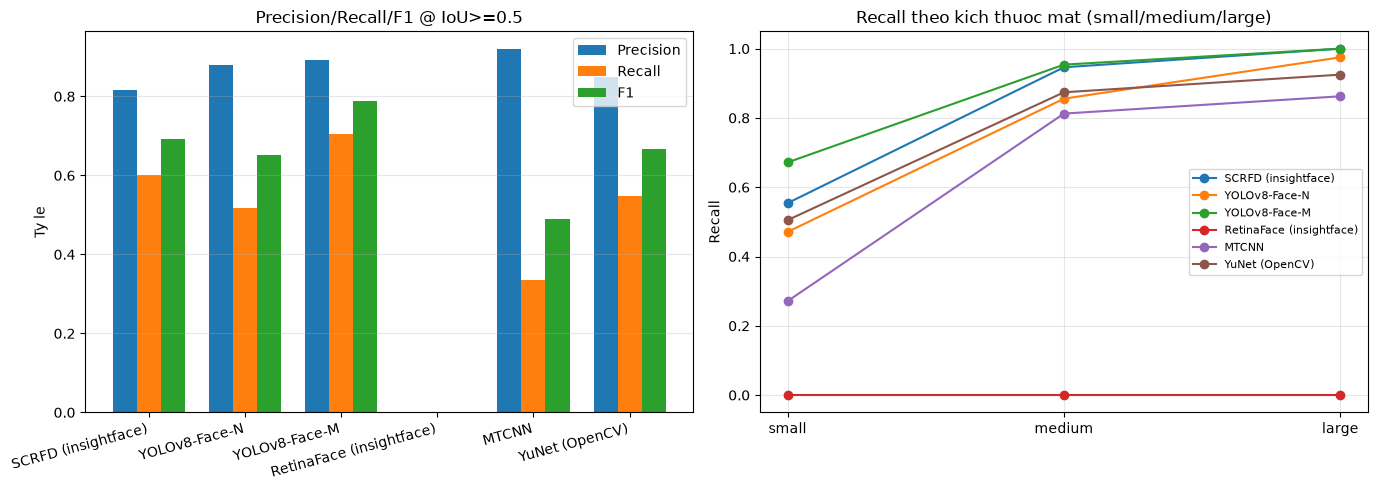

Da luu bieu do: D:\face-security-system\ai\dataset\evaluation_results\face_detector_comparison.png


In [18]:
# ===== CELL B7: Bieu do so sanh Precision/Recall/F1 + Recall theo kich thuoc mat =====
import matplotlib.pyplot as plt

if not WIDER_FACE_AVAILABLE:
    print("Bo qua Cell nay - WIDER FACE chua san sang")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bieu do 1: Precision/Recall/F1 tong the
    x = np.arange(len(summary_df))
    width = 0.25
    axes[0].bar(x - width, summary_df["precision"], width, label="Precision")
    axes[0].bar(x, summary_df["recall"], width, label="Recall")
    axes[0].bar(x + width, summary_df["f1"], width, label="F1")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(summary_df["model"], rotation=15, ha="right")
    axes[0].set_ylabel("Ty le")
    axes[0].set_title(f"Precision/Recall/F1 @ IoU>={IOU_THRESHOLD}")
    axes[0].legend()
    axes[0].grid(alpha=0.3, axis="y")

    # Bieu do 2: Recall theo kich thuoc mat - moi model 1 duong
    for model_name in DETECTORS.keys():
        sub = recall_by_size[recall_by_size["model"] == model_name]
        axes[1].plot(sub["size_bucket"].astype(str), sub["recall"], marker="o", label=model_name)
    axes[1].set_ylabel("Recall")
    axes[1].set_title("Recall theo kich thuoc mat (small/medium/large)")
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plot_path = os.path.join(RESULTS_DIR, "face_detector_comparison.png")
    plt.savefig(plot_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Da luu bieu do: {plot_path}")


## Phan C - Do toc do (FPS) tren GPU / CPU baseline

Accuracy khong phai tat ca - he thong nay chay **real-time tren stream camera**
(`backend/app/services/pipeline_runner.py`), nen toc do quyet dinh model co dung duoc
cho production hay khong, khong chi de trong bao cao. Do bang cach chay 100 anh lien tiep
qua tung model, tinh FPS trung binh (bo qua vai lan dau de "warm-up" GPU/model).

In [19]:
# ===== CELL C1: Do FPS cho ca 6 model tren cung tap anh, cung GPU / CPU baseline =====
import time

N_WARMUP = 5
N_TIMED = 100

speed_results = []

if not WIDER_FACE_AVAILABLE:
    print("Bo qua Cell nay - can anh WIDER FACE de do FPS tren du lieu thuc te")
else:
    timing_images = []
    for img_rel_path in list(wider_annotations.keys())[:N_WARMUP + N_TIMED]:
        img = cv2.imread(os.path.join(WIDER_VAL_IMAGES_DIR, img_rel_path))
        if img is not None:
            timing_images.append(img)

    for model_name, detect_fn in DETECTORS.items():
        print(f"Dang do toc do {model_name}...")

        # Warm-up - lan chay dau tien cua GPU model thuong cham hon han do khoi tao kernel CUDA
        for img in timing_images[:N_WARMUP]:
            detect_fn(img)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start = time.time()
        for img in timing_images[N_WARMUP:N_WARMUP + N_TIMED]:
            detect_fn(img)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        elapsed = time.time() - start

        n_processed = len(timing_images[N_WARMUP:N_WARMUP + N_TIMED])
        fps = n_processed / elapsed if elapsed > 0 else 0.0
        ms_per_image = (elapsed / n_processed) * 1000 if n_processed > 0 else 0.0

        speed_results.append({
            "model": model_name, "fps": round(fps, 2),
            "ms_per_image": round(ms_per_image, 2), "n_images_timed": n_processed,
        })

    speed_df = pd.DataFrame(speed_results)
    print(f"\nToc do xu ly (batch size = 1, {'GPU: ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}):\n")
    print(speed_df.to_string(index=False))
    speed_df.to_csv(os.path.join(RESULTS_DIR, "face_detector_comparison_speed.csv"), index=False)


Dang do toc do SCRFD (insightface)...


d:\face-security-system\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


Dang do toc do YOLOv8-Face-N...
Dang do toc do YOLOv8-Face-M...
Dang do toc do RetinaFace (insightface)...
Dang do toc do MTCNN...
Dang do toc do YuNet (OpenCV)...

Toc do xu ly (batch size = 1, GPU: NVIDIA GeForce RTX 5070):

                   model    fps  ms_per_image  n_images_timed
     SCRFD (insightface)   4.37        229.04             100
           YOLOv8-Face-N 155.87          6.42             100
           YOLOv8-Face-M  70.92         14.10             100
RetinaFace (insightface)   8.55        116.99             100
                   MTCNN   8.98        111.33             100
          YuNet (OpenCV)  25.61         39.04             100


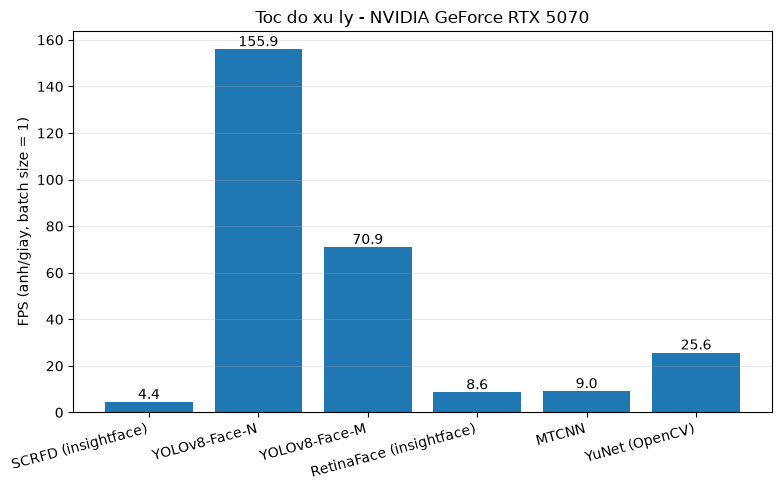

Da luu bieu do: D:\face-security-system\ai\dataset\evaluation_results\face_detector_speed_comparison.png


In [20]:
# ===== CELL C2: Bieu do FPS =====
if not WIDER_FACE_AVAILABLE:
    print("Bo qua Cell nay - chua co ket qua toc do")
else:
    plt.figure(figsize=(8, 5))
    bars = plt.bar(speed_df["model"], speed_df["fps"])
    plt.ylabel("FPS (anh/giay, batch size = 1)")
    plt.title("Toc do xu ly - " + (torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"))
    plt.xticks(rotation=15, ha="right")
    for bar, fps in zip(bars, speed_df["fps"]):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{fps:.1f}",
                  ha="center", va="bottom")
    plt.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plot_path = os.path.join(RESULTS_DIR, "face_detector_speed_comparison.png")
    plt.savefig(plot_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Da luu bieu do: {plot_path}")


## Phan D - So sanh truc quan tren vai anh mau

Ve bounding box cua ca 6 model tren cung 1 anh, canh nhau - de "nhin thay bang mat"
khac biet (vi du MTCNN co the bo sot mat nho trong dam dong ma SCRFD/YOLOv8-Face-N / YOLOv8-Face-M bat
duoc), bo sung truc quan cho bang so lieu o Phan B.

d:\face-security-system\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


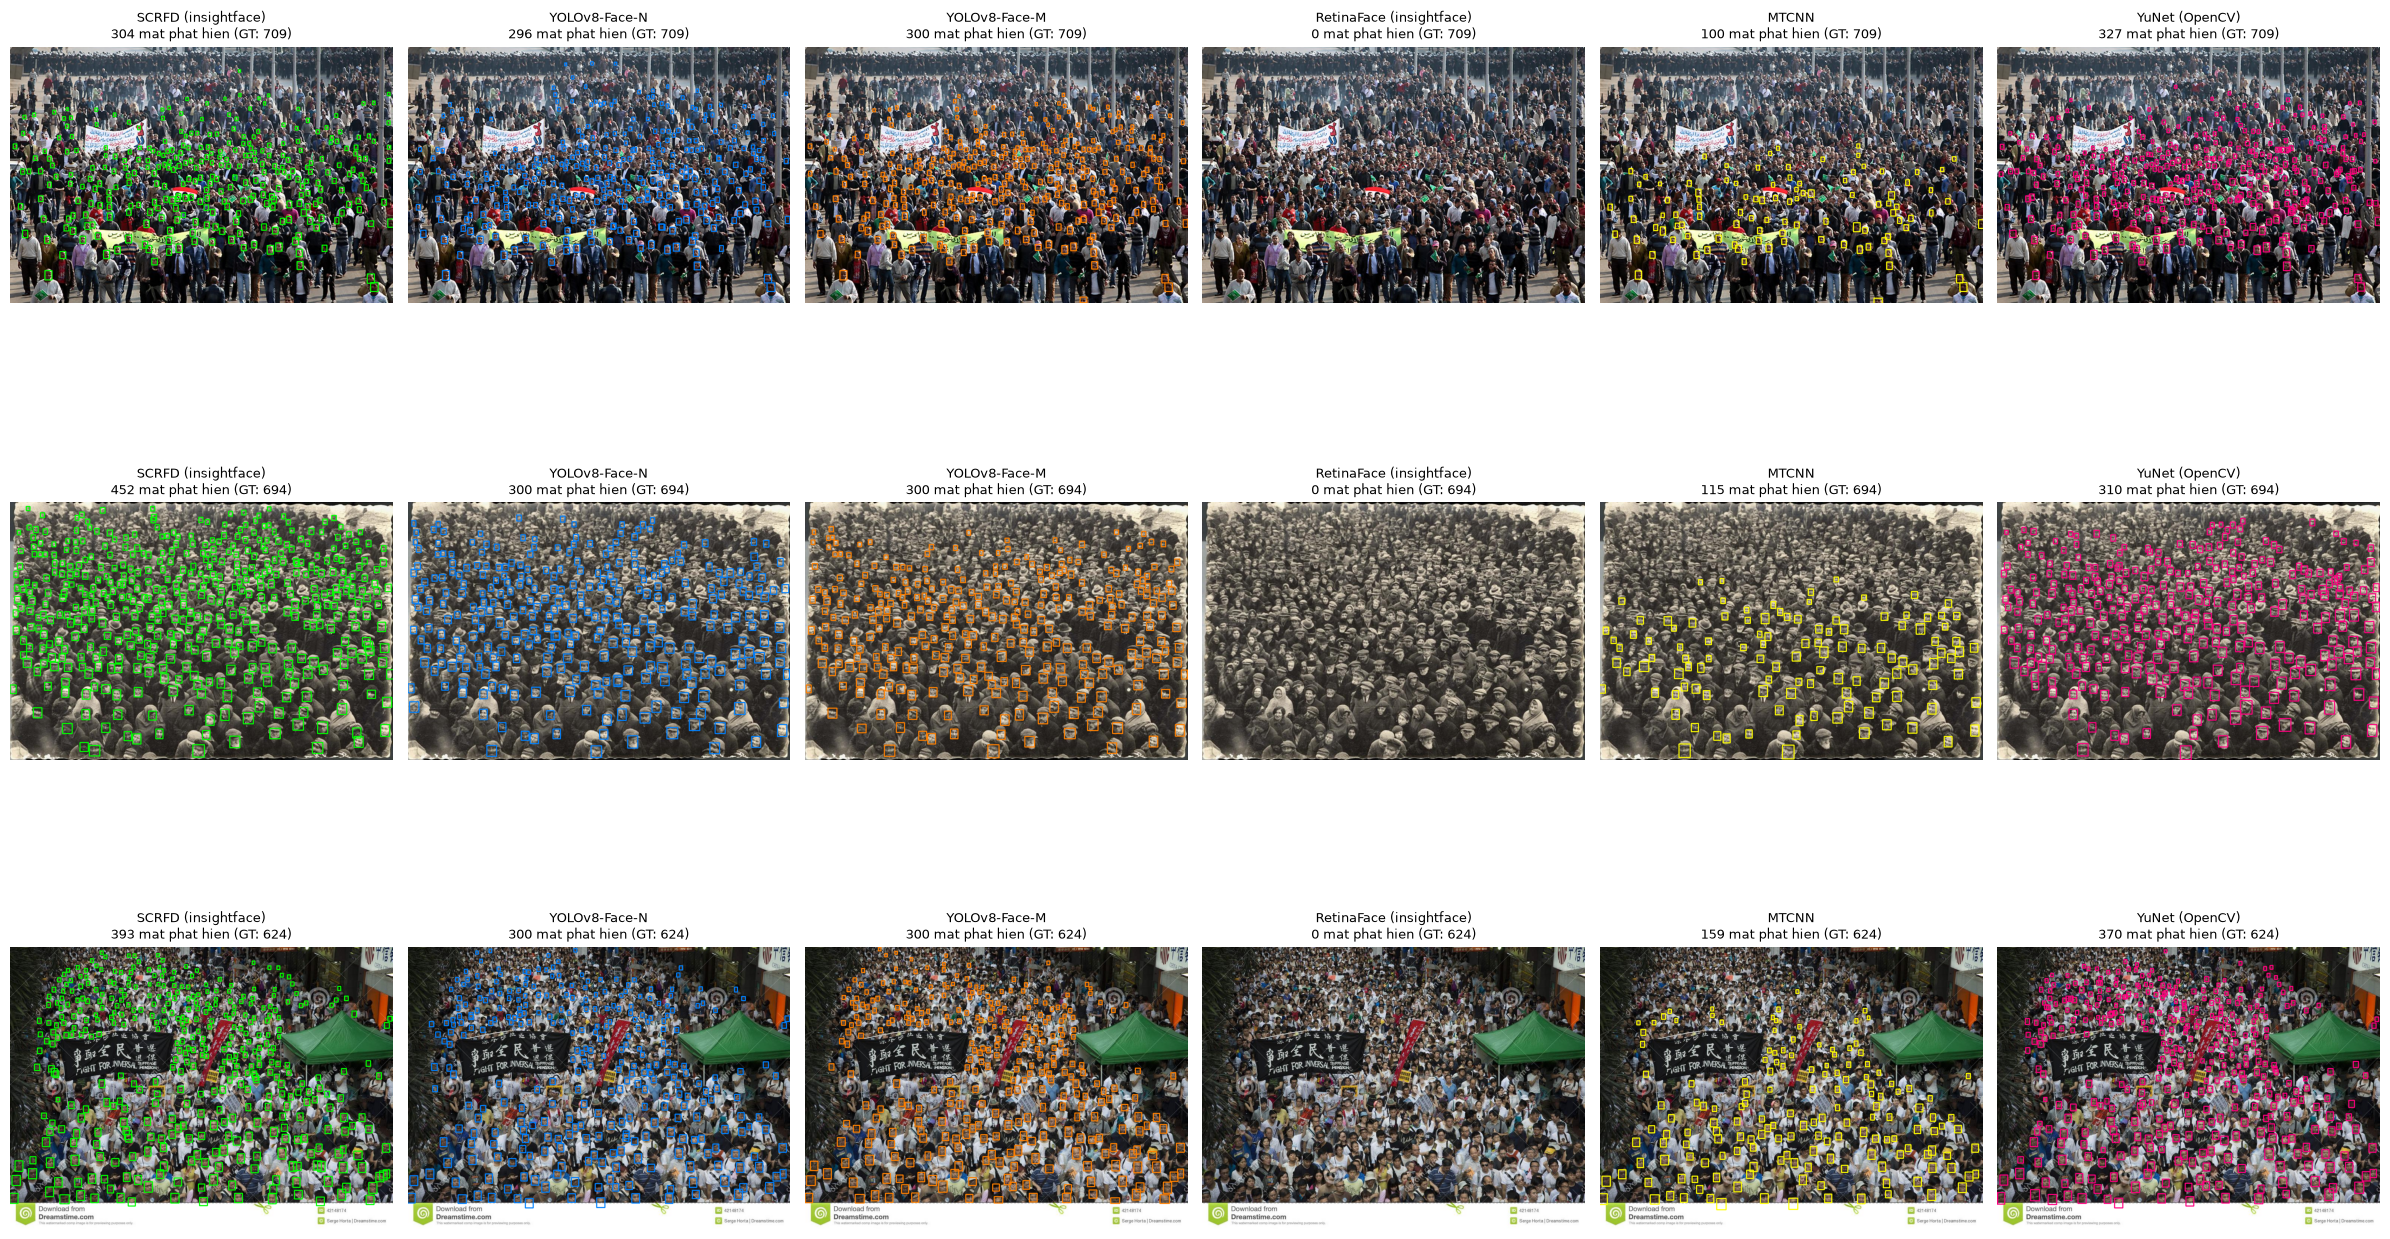

Da luu anh so sanh: D:\face-security-system\ai\dataset\evaluation_results\face_detector_visual_comparison.png


In [21]:
# ===== CELL D1: Ve bounding box cua ca 6 model tren vai anh mau tu WIDER FACE =====
N_SAMPLE_IMAGES = 3
MODEL_NAMES = list(DETECTORS.keys())
DEFAULT_BGR_COLORS = [
    (0, 255, 0),
    (255, 128, 0),
    (0, 128, 255),
    (255, 0, 255),
    (0, 255, 255),
    (128, 0, 255),
]
COLORS = {name: DEFAULT_BGR_COLORS[i % len(DEFAULT_BGR_COLORS)] for i, name in enumerate(MODEL_NAMES)}

if not WIDER_FACE_AVAILABLE:
    print("Bo qua Cell nay - WIDER FACE chua san sang")
else:
    # Uu tien anh co nhieu mat (dam dong) de thay ro khac biet giua cac model
    sample_keys = sorted(wider_annotations.keys(), key=lambda k: -len(wider_annotations[k]))[:N_SAMPLE_IMAGES]

    fig, axes = plt.subplots(N_SAMPLE_IMAGES, len(DETECTORS), figsize=(4 * len(DETECTORS), 5 * N_SAMPLE_IMAGES))
    if N_SAMPLE_IMAGES == 1:
        axes = axes.reshape(1, -1)

    for row, img_rel_path in enumerate(sample_keys):
        img_bgr = cv2.imread(os.path.join(WIDER_VAL_IMAGES_DIR, img_rel_path))

        for col, (model_name, detect_fn) in enumerate(DETECTORS.items()):
            vis = img_bgr.copy()
            boxes = detect_fn(img_bgr)
            for x1, y1, x2, y2 in boxes:
                cv2.rectangle(vis, (x1, y1), (x2, y2), COLORS[model_name], 2)

            axes[row, col].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
            axes[row, col].set_title(f"{model_name}\n{len(boxes)} mat phat hien "
                                      f"(GT: {len(wider_annotations[img_rel_path])})", fontsize=9)
            axes[row, col].axis("off")

    plt.tight_layout()
    plot_path = os.path.join(RESULTS_DIR, "face_detector_visual_comparison.png")
    plt.savefig(plot_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Da luu anh so sanh: {plot_path}")


## Phan E - Tong ket

**Ket qua luu trong `ai/dataset/evaluation_results/`:**
- `face_detector_comparison_summary.csv` - Precision/Recall/F1 tong the tung model
- `face_detector_comparison_recall_by_size.csv` - recall theo kich thuoc mat (small/medium/large)
- `face_detector_comparison_speed.csv` - FPS/ms-per-image tren GPU / CPU baseline
- `face_detector_comparison.png`, `face_detector_speed_comparison.png`,
  `face_detector_visual_comparison.png` - cac bieu do

**Cach doc ket qua cho bao cao (Chuong 4):**
- Khi mo bang tong hop, se co 6 dong tuong ung 6 model.
- Nhom `small` la quan trong nhat cho bai toan giam sat an ninh, vi mat nho xa camera
  thuong la tinh huong thuc te nhat.
- Neu can chon 1 model de dua vao he thong, uu tien xet dong thoi: recall `small`,
  F1 tong the, va FPS tren GPU RTX 5070.
- SCRFD hien tai van la model `dang dung that` trong backend, nen ket qua notebook nay
  la co so de bao ve quyet dinh kien truc trong bao cao va presentation.
